# Baseline empirical threshold (ER, exponential)

Analyse van het baseline drempelexperiment op een ER-netwerk met exponentieel herstel.

Dit notebook gaat uit van:
- `python scripts/run_pipeline.py --all` is gedraaid,
- het BehaviorSpace-experiment `05-baseline-empirical-threshold-ER` bestaat in `NetLogo/behaviorspace_experiments.xml` en schrijft een `05-baseline-empirical-threshold-ER_table.csv` onder `output/raw/`.


In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "NetLogo" / "virus_simulation.nlogox").is_file():
            return p
    raise FileNotFoundError(
        "Could not find NetLogo/virus_simulation.nlogox. Open the repo root in Cursor (File → Open Folder)."
    )


ROOT = _project_root()
OUT = ROOT / "output"
RAW = OUT / "raw"
LAMBDA_PATH = OUT / "lambda_max.csv"

import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scripts.analysis_utils as _analysis_utils
import scripts.threshold_estimators as _threshold_estimators

net_label_from_network_type = _analysis_utils.net_label_from_network_type
read_behaviorspace_table = _analysis_utils.read_behaviorspace_table
survival_curve = _threshold_estimators.survival_curve

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
ROOT

WindowsPath('C:/Dossiers/Master AI/Research Methods for AI (IM1312)/RMAI Research Project')

In [ ]:
# Load lambda_max (if available) and the baseline ER table
lam = pd.read_csv(LAMBDA_PATH) if LAMBDA_PATH.is_file() else None
if lam is not None:
    lam["net_label"] = lam["net_label"].astype(str)

baseline_name = "05-baseline-empirical-threshold-ER"
baseline_csv = RAW / f"{baseline_name.replace(' ', '_')}_table.csv"
if not baseline_csv.is_file():
    raise FileNotFoundError(f"Missing {baseline_csv}. Run: python scripts/run_pipeline.py --all")

runs = read_behaviorspace_table(baseline_csv)

# Normaliseer kolomnamen zoals in sis_threshold_analysis
def _pick(df: pd.DataFrame, *candidates: str) -> str:
    import re as _re

    def _norm(name: object) -> str:
        return (
            _re.sub(r"\s+", "_", str(name).strip().strip('"').lower())
            .replace("[", "")
            .replace("]", "")
            .replace("-", "_")
        )

    idx = {_norm(c): c for c in df.columns}
    for cand in candidates:
        k = _norm(cand)
        if k in idx:
            return idx[k]
    raise KeyError(f"Could not resolve any of {candidates} in columns: {list(df.columns)}")

net_col = _pick(
    runs,
    "interconnection_structure",
    "interconnection-structure",
    "network_type",
    "network-type",
)
inf_col = _pick(
    runs,
    "infection_prob",
    "infection-prob",
    "infection prob",
    "[infection-prob]",
)
ext_col = _pick(runs, "bs_out_extinct", "bs-out-extinct")

runs["net_label"] = runs[net_col].map(net_label_from_network_type)
runs["infection_prob"] = pd.to_numeric(runs[inf_col], errors="coerce")
runs["extinct"] = runs[ext_col].astype(bool)

er_only = runs[runs["net_label"] == "ER"].copy() if "ER" in set(runs["net_label"]) else runs.copy()

curve = survival_curve(
    er_only,
    inf_col="infection_prob",
    ext_col="extinct",
)
curve

,infection_prob,n,p_survive
0,0.013926,100,0.00
1,0.020890,100,0.00
2,0.027853,100,0.00
3,0.034816,100,0.00
4,0.041779,100,0.07


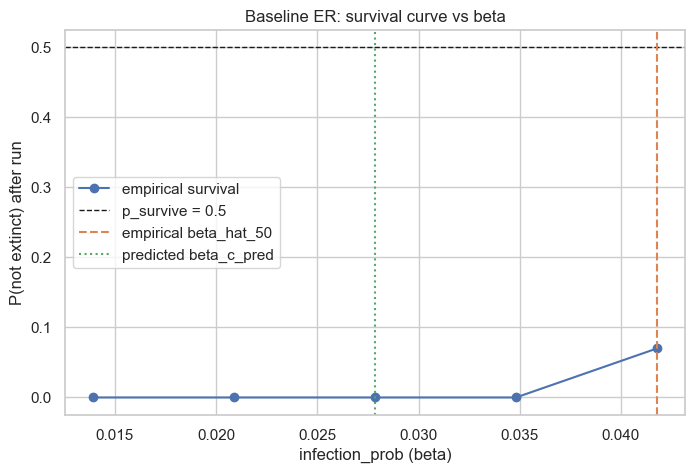

Approx. beta_hat_surv_50 (ER baseline) = 0.041779
beta_c^pred (1/(lambda_max * E[W])) = 0.027853
ratio beta_hat_surv_50 / beta_c^pred = 1.500


In [ ]:
# Plot survival curve and approximate beta_hat_surv_50
fig, ax = plt.subplots()
ax.plot(curve["infection_prob"], curve["p_survive"], marker="o", label="empirical survival")
ax.axhline(0.5, color="k", linestyle="--", linewidth=1, label="p_survive = 0.5")
ax.set_xlabel("infection_prob (beta)")
ax.set_ylabel("P(not extinct) after run")
ax.set_title("Baseline ER: survival curve vs beta")

# Eenvoudige lineaire interpolatie voor p_survive = 0.5
beta = curve["infection_prob"].to_numpy()
p = curve["p_survive"].to_numpy()
beta_hat = np.interp(0.5, p, beta)

# Vertical line at empirical threshold
ax.axvline(beta_hat, color="C1", linestyle="--", label="empirical beta_hat_50")

# Vertical line at spectral prediction, if available
beta_c_pred = None
if lam is not None and (lam["net_label"] == "ER").any():
    row_er = lam.query("net_label == 'ER'").iloc[0]
    lambda_max_er = float(row_er["lambda_max"])
    # recovery_mean is in the NetLogo experiment (e.g. 5)
    recovery_mean = 5.0
    beta_c_pred = 1.0 / (lambda_max_er * recovery_mean)
    ax.axvline(beta_c_pred, color="C2", linestyle=":", label="predicted beta_c_pred")

ax.legend()
plt.show()

print(f"Approx. beta_hat_surv_50 (ER baseline) = {beta_hat:.6f}")

if beta_c_pred is not None:
    print(f"beta_c^pred (1/(lambda_max * E[W])) = {beta_c_pred:.6f}")
    print(f"ratio beta_hat_surv_50 / beta_c^pred = {beta_hat / beta_c_pred:.3f}")
else:
    print("No ER row in lambda_max.csv; cannot compare to spectral prediction.")
